In [1]:
import os
import json
import matplotlib.pyplot as plt

%matplotlib inline

#### Data loading

In [2]:
root_json = "/mnt/ssd/datasets/deepfake/dataset_json"
#print(sorted(os.listdir("/mnt/ssd/datasets/deepfake/dataset_json")))
os.chdir(root_json)

In [3]:
dataset_name = "200k_live_face_dataset"
path_json = os.path.join(root_json,dataset_name+".json")

In [4]:
with open(path_json, 'r') as file:
    data = json.load(file)

In [5]:
list_keys = list(data.keys())

In [6]:
path_img = data[list_keys[4]]["processed_path"]
print(path_img)

/mnt/ssd/datasets/deepfake/200k_live_face_dataset/processes/live/face/186513_verify_4ff2e9b4-0edc-4a54-8431-9ea9931dc19e_33e66bd6-0507-4b66-bf11-efa24e7b8cf4_original.jpg.jpg


#### Profile Prediction

In [7]:
from face_detection import FaceDetection
import age_detection as ad
import cv2

fd = FaceDetection() # face detection wrapper

ad_m = ad.AgeClassification()

Model warm-up completed with 1 runs.
Model warm-up completed with 1 runs.
Model warm-up completed with 1 runs.


/home/a.nugroho/miniforge3/envs/deepfake_dataset/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/a.nugroho/miniforge3/envs/deepfake_dataset/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/a.nugroho/miniforge3/envs/deepfake_dataset/lib/python3.9/site-packages/age_detection/main.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data whic

30-39


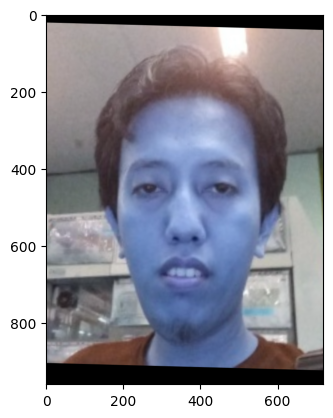

In [13]:
# read sample image from file
img = cv2.imread(path_img)

# get face detection result
dets, angle = fd.predict(img, validate_all_faces=True, strict_level="medium")

# Age
out = fd.extract_face(img,dets,angle, task="face-iso")
img_aligned = out

print(ad_m.predict(img_aligned))

plt.imshow(img_aligned)
# Gender

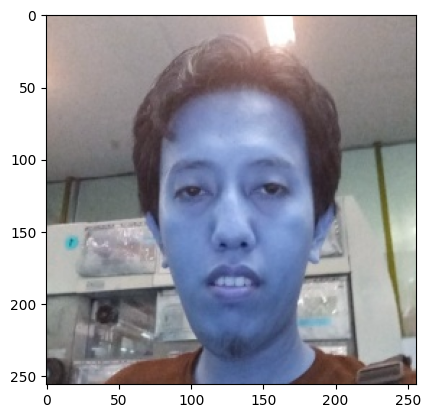

In [14]:
plt.imshow(img)

#### Face Pose/Angle/Orientation

In [7]:
from face_detection import FaceDetection
from face_quality_assessment import FaceQualityAssessment 
import cv2

fd = FaceDetection() # face detection wrapper

/home/a.nugroho/miniforge3/envs/deepfake_dataset/lib/python3.9/site-packages/openvino/runtime/__init__.py:10: DeprecationWarning: The `openvino.runtime` module is deprecated and will be removed in the 2026.0 release. Please replace `openvino.runtime` with `openvino`.
  warnings.warn(


Model warm-up completed with 1 runs.
Model warm-up completed with 1 runs.
Model warm-up completed with 1 runs.


In [8]:
# read sample image from file
img = cv2.imread(path_img)


In [9]:
# get face detection result
dets, angle = fd.predict(img)

In [10]:
image, scale, pads = fd.processor.prepare_image(img)

In [11]:
outputs = fd.headpose_detector.infer(image, dets[:, :4])
#headposes = self.postprocess(outputs)

In [ ]:
yaw, pitch, roll = outputs[0]
print(outputs[0])

<class 'numpy.ndarray'>


#### Image Quality

In [1]:
from face_detection import FaceDetection
from face_quality_assessment import FaceQualityAssessment 
import cv2

fd = FaceDetection() # face detection wrapper
qa = FaceQualityAssessment()


/home/a.nugroho/miniforge3/envs/deepfake_dataset/lib/python3.9/site-packages/openvino/runtime/__init__.py:10: DeprecationWarning: The `openvino.runtime` module is deprecated and will be removed in the 2026.0 release. Please replace `openvino.runtime` with `openvino`.
  warnings.warn(


Model warm-up completed with 1 runs.
Model warm-up completed with 1 runs.
Model warm-up completed with 1 runs.


In [14]:
# read sample image from file
img = cv2.imread(path_img)

# get face detection result
dets, angle = fd.predict(img)

# get crop_single_face with loose_factor=1.25
img_cropped, _ = fd.crop_single_face(img, dets, angle, loose_factor = 1.25)

# get blur score
blur_score = qa.blur.blur_score_selfie(img_cropped)

# get blur detection
is_blur = qa.blur.blur_detection(blur_score)

# get dark score
dark_score = qa.dark.contrast_score_selfie(img_cropped)

# get dark detection
is_dark = qa.dark.contrast_detection(dark_score)

# get grayscale score
raw_score = qa.grayscale.grayscale_score_selfie_raw(img_cropped)

# get the grayscale detection
is_gray = qa.grayscale.grayscale_detection(raw_score)

# get the blur score
blur_score = qa.image_quality.quality_score_selfie(img)

# get the blur detection
is_blur = qa.image_quality.blur_detection(blur_score)

print(f"{is_blur}, {is_dark},{is_gray}, {is_blur}")


False, False,False, False


#### Deepfake Smoothness

In [20]:
from face_deepfake import DeepfakeDetection
fdd = DeepfakeDetection()

In [21]:
# crop the image
img_cropped_df, bbox = fd.crop_single_face(
    img, dets, angle, loose_factor=1.3, crop_size=None,square=True
)

In [24]:
# get deepfake score
deepfake_score = fdd.predict(img_cropped_df)

# get deepfake decision
is_deepfake = fdd.classify_predictions(deepfake_score)

print(f"{is_deepfake}")


False


#### Skin Tone Classifier

In [16]:
import stone

In [20]:
# process the image
result = stone.process(path_img, return_report_image=True)
# show the report image
#report_images = result.pop("report_images")  # obtain and remove the report image from the `result`
#face_id = 1
#stone.show(report_images[face_id])

In [25]:
result["faces"]

[{'dominant_colors': [{'color': '#C5A293', 'percent': '0.52'},
   {'color': '#946C5F', 'percent': '0.48'}],
  'skin_tone': '#9D7A54',
  'tone_label': 'BF',
  'accuracy': 86.15,
  'face_id': 1}]

#### Gender Prediction

In [2]:
import insightface
from insightface.app import FaceAnalysis
from insightface.data import get_image as ins_get_image

ctx = 0
app = FaceAnalysis(allowed_modules=['detection', 'genderage'])
app.prepare(ctx_id=ctx, det_size=(640,640))

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/a.nugroho/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/a.nugroho/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/a.nugroho/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/a.nugroho/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/a.nugroho/.insightface/models/buffalo_l/w600k_r50.onnx recognition
set det-size: (640, 640)


In [2]:
faces = app.get(img_aligned)

NameError: name 'img_aligned' is not defined

In [ ]:
if faces[0]['gender']==0:
    gender_now = 'MALE'
elif faces[0]['gender']==1:
    gender_now = 'FEMALE'
else:
    gender_now = "OTHER"

print(gender_now)
   

MALE


#### Notes

In [38]:
# read sample image from file
img = cv2.imread(path_img)
print(img.shape)
path_img

(256, 256, 3)


'/mnt/ssd/datasets/deepfake/200k_live_face_dataset/processes/live/face/186513_verify_4ff2e9b4-0edc-4a54-8431-9ea9931dc19e_33e66bd6-0507-4b66-bf11-efa24e7b8cf4_original.jpg.jpg'

In [ ]:
# load the image 
img = cv2.imread("samples/blur.jpg")

# get the blur score
blur_score = qa.image_quality.quality_score_selfie(img)

# get the blur detection
is_blur = qa.image_quality.blur_detection(blur_score)

#